In [4]:
import os, glob, gc, cudf
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import warnings

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

# 1. CẤU HÌNH ĐƯỜNG DẪN GỐC
ROOT_PATH = '/kaggle/input/datasets/qyn041220ntt/ics-nad/Dataset'

# 2. CỘT GÂY RÒ RỈ (Xóa ngay để mô hình học hành vi, không học vẹt IP/MAC)
LEAKAGE_COLS = [
    'sAddress', 'rAddress', 'sMACs', 'rMACs', 'sIPs', 'rIPs', 'protocol',
    'startDate', 'endDate', 'start', 'end', 'startOffset', 'endOffset'
]

# 3. MAPPING NHÃN (Xử lý lỗi chính tả và chữ hoa/thường cho cả 2 bộ)
LABEL_MAPPING = {
    'ACKPFLOOD': 'ACKFLOOD',
    'SMURF': 'SMURF', 'Smurf': 'SMURF',
    'FRAGGLE': 'FRAGGLE', 'Fraggle': 'FRAGGLE',
    'WINNUKE': 'WINNUKE', 'WinNuke': 'WINNUKE',
    'TCP': 'FDI_WRONG_FLAGS', 'SYN': 'FDI_WRONG_FLAGS',
    'ICMPBIG': 'ICMP_BIG_PKT',
    'ICMPREDIRECT': 'ICMP_REDIRECT',
    'ICMPNOTREATH': 'ICMP_NOT_REACH',
    'ICMPNOTREACH': 'ICMP_NOT_REACH',
    'PINGOFDEATH': 'POD'
}

 Device: cuda


In [5]:
schneider_files = glob.glob(f'{ROOT_PATH}/Schneider/*.csv')
siemens_files = glob.glob(f'{ROOT_PATH}/Siemens/*.csv')

print(f" Schneider: {len(schneider_files)} files")
print(f" Siemens: {len(siemens_files)} files")

 Schneider: 27 files
 Siemens: 16 files


In [6]:
def get_dynamic_met_groups(unique_labels):
    """
    Phân loại các nhãn dựa trên 4 nhóm tấn công chuẩn của ICS-NAD.
    - CLOSED: BENIGN + Các loại Flood lớn.
    - OPPONENT: Các biến thể DoS.
    - OPEN (Zero-day): MitM, FDI, Recon.
    """
    groups = {'CLOSED': [], 'OPPONENT': [], 'OPEN': []}
    
    clean_labels = [str(l).strip().upper() for l in unique_labels]

    rules = {
        'CLOSED': ['BENIGN', 'ACKFLOOD', 'SYNFLOOD', 'ICMPFLOOD'],
        'OPPONENT': ['SMURF', 'FRAGGLE', 'TEARDROP', 'LAND', 'WINNUKE', 'POD'],
        'OPEN': ['ICMP_BIG_PKT', 'ICMP_REDIRECT', 'ICMP_NOT_REACH', 'FDI_WRONG_FLAGS', 'ARP', 'PORTSCAN', 'ROUTEIP']
    }

    for label in clean_labels:
        if label in rules['CLOSED']:
            groups['CLOSED'].append(label)
        elif label in rules['OPPONENT']:
            groups['OPPONENT'].append(label)
        elif label in rules['OPEN']:
            groups['OPEN'].append(label)
            
    return groups

In [7]:
def run_ics_pipeline(vendor_name, sample_rate=0.05, max_samples_per_class=10000):
    print(f"\n ĐANG XỬ LÝ: {vendor_name.upper()}")
    
    # 1. TÌM FILE VÀ LOAD
    path = os.path.join(ROOT_PATH, vendor_name)
    files = sorted(glob.glob(f'{path}/*.csv'))
    
    # Skip files lỗi (Siemens)
    skip = ['Siemens_tcpall0_0709.csv', 'Siemens_tcpsynfin0_0709.csv', 
            'Siemens_teardrop_0709.csv', 'Siemens_tcpfin1_0709.csv']
    files = [f for f in files if os.path.basename(f) not in skip]
    
    all_dfs = []
    for f in tqdm(files, desc="Loading CSVs"):
        try:
            df_gpu = cudf.read_csv(f)
            if 'state' in df_gpu.columns: 
                df_gpu = df_gpu.rename(columns={'state': 'label'})
            
            # Xóa leakage columns
            drops = [c for c in LEAKAGE_COLS if c in df_gpu.columns]
            df_gpu = df_gpu.drop(columns=drops)
            
            # Chuẩn hóa nhãn
            df_cpu = df_gpu.to_pandas()
            df_cpu['label'] = df_cpu['label'].astype(str).str.upper().str.strip().replace(LABEL_MAPPING)
            
            # Downsampling để tránh tràn RAM Kaggle
            df_cpu = df_cpu.sample(frac=sample_rate, random_state=42)
            all_dfs.append(df_cpu)
            
            del df_gpu;
            gc.collect()
        except Exception as e: 
            continue
            
    df_full = pd.concat(all_dfs, ignore_index=True)
    
    # 2. PHÂN NHÓM NHÃN
    groups = get_dynamic_met_groups(df_full['label'].unique())
    print(f"\n Kết quả phân nhóm nhãn cho {vendor_name}:")
    print(f" - Closed (Train): {groups['CLOSED']}")
    print(f" - Opponent (Train/Uncertainty): {groups['OPPONENT']}")
    print(f" - Open (Zero-day Test): {groups['OPEN']}")
    
    # 3. CHIA TẬP VÀ CÂN BẰNG LỚP
    df_zero = df_full[df_full['label'].isin(groups['OPEN'])].copy()
    df_trainable = df_full[df_full['label'].isin(groups['CLOSED'] + groups['OPPONENT'])].copy()

    # Cân bằng lớp chống overfit nhóm Flood
    df_trainable = df_trainable.groupby('label',group_keys=False).apply(
        lambda x: x.sample(min(len(x), max_samples_per_class), random_state=42), 
    ).reset_index(drop=True)
    
    X = df_trainable.drop(columns=['label'])
    y = df_trainable['label']
    
    # Chia Train/Test cho tập đã biết
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # 4. CHỌN ĐẶC TRƯNG & CHUẨN HÓA (CHỈ FIT TRÊN TRAIN)
    rf = RandomForestClassifier(n_estimators=30, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    top_features = pd.Series(rf.feature_importances_, index=X_train.columns).nlargest(15).index.tolist()
    print(f"\n Top 15 đặc trưng: {top_features[:15]}")
    
    scaler = MinMaxScaler()
    # Fit duy nhất trên X_train để đảm bảo Zero-day và Test là hoàn toàn mới
    X_train_scaled = scaler.fit_transform(X_train[top_features])
    X_test_scaled = scaler.transform(X_test[top_features])
    X_zero_scaled = scaler.transform(df_zero[top_features])

    # THANH TẨY DỮ LIỆU (Replace NaN bằng 0, Inf bằng giá trị lớn/nhỏ nhất hữu hạn)
    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=1e6, neginf=-1e6)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=1e6, neginf=-1e6)
    X_zero_scaled = np.nan_to_num(X_zero_scaled, nan=0.0, posinf=1e6, neginf=-1e6)
    
    print(f"\n Đã chuẩn bị xong dữ liệu {vendor_name}!")
    return X_train_scaled, X_test_scaled, X_zero_scaled, y_train, y_test, df_zero['label'], top_features

In [8]:
print("\n" + "="*60)
print("Define MET Few-shot Network")
print("="*60)

class TabularFeatureTokenizer(nn.Module):
    """Feature Tokenizer for Tabular Data"""
    
    def __init__(self, num_features=15, embedding_dim=256):
        super(TabularFeatureTokenizer, self).__init__()
        self.num_features = num_features
        self.embedding_dim = embedding_dim
        
        # Individual weights and biases per feature
        self.weight = nn.Parameter(torch.Tensor(num_features, embedding_dim))
        self.bias = nn.Parameter(torch.Tensor(num_features, embedding_dim))
        
        nn.init.normal_(self.weight, std=0.01)
        nn.init.zeros_(self.bias)

    def forward(self, x):
        """
        Input: (batch_size, num_features)
        Output: (batch_size, num_features, embedding_dim)
        """
        x = x.unsqueeze(-1)  # (B, F, 1)
        tokens = x * self.weight + self.bias  # (B, F, D)
        return tokens
        
class FT_Transformer_Backbone(nn.Module):
    """FT-Transformer Backbone with [CLS] token"""
    
    def __init__(self, num_features=15, embedding_dim=256, num_layers=2, nhead=8, dropout=0.1):
        super(FT_Transformer_Backbone, self).__init__()
        
        self.tokenizer = TabularFeatureTokenizer(num_features, embedding_dim)
        
        # [CLS] token
        self.cls_token = nn.Parameter(torch.Tensor(1, 1, embedding_dim))
        nn.init.normal_(self.cls_token, std=0.01)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=nhead,
            dim_feedforward=embedding_dim * 2,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
    
    def forward(self, x):
        """
        Input: (batch_size, num_features)
        Output: (batch_size, embedding_dim)
        """
        batch_size = x.size(0)
        
        # Tokenize features
        feature_tokens = self.tokenizer(x)  # (B, F, D)
        
        # Prepare [CLS] token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)  # (B, 1, D)
        
        # Concatenate
        transformer_input = torch.cat((cls_tokens, feature_tokens), dim=1)  # (B, 1+F, D)
        
        # Transformer
        transformer_output = self.transformer(transformer_input)  # (B, 1+F, D)
        
        # Extract [CLS] representation
        global_representation = transformer_output[:, 0, :]  # (B, D)
        
        return global_representation

class ScaledDotProductAttention(nn.Module):
    def __init__(self, temperature, attn_dropout=0.1):
        super().__init__()
        self.temperature = temperature
        self.dropout = nn.Dropout(attn_dropout)
        self.softmax = nn.Softmax(dim=2)
    
    def forward(self, q, k, v):
        attn = torch.bmm(q, k.transpose(1, 2))
        attn = attn / self.temperature
        attn = self.softmax(attn)
        attn = self.dropout(attn)
        output = torch.bmm(attn, v)
        return output, attn

class MultiHeadAttention(nn.Module):
    def __init__(self, n_head, d_model, d_k, d_v, dropout=0.1):
        super().__init__()
        self.n_head = n_head
        self.d_k = d_k
        self.d_v = d_v
        
        self.w_qs = nn.Linear(d_model, n_head * d_k, bias=False)
        self.w_ks = nn.Linear(d_model, n_head * d_k, bias=False)
        self.w_vs = nn.Linear(d_model, n_head * d_v, bias=False)
        
        self.attention = ScaledDotProductAttention(temperature=np.power(d_k, 0.5))
        self.layer_norm = nn.LayerNorm(d_model)
        self.fc = nn.Linear(n_head * d_v, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, q, k, v):
        d_k, d_v, n_head = self.d_k, self.d_v, self.n_head
        sz_b, len_q, _ = q.size()
        sz_b, len_k, _ = k.size()
        sz_b, len_v, _ = v.size()
        
        residual = q
        q = self.w_qs(q).view(sz_b, len_q, n_head, d_k)
        k = self.w_ks(k).view(sz_b, len_k, n_head, d_k)
        v = self.w_vs(v).view(sz_b, len_v, n_head, d_v)
        
        q = q.permute(2, 0, 1, 3).contiguous().view(-1, len_q, d_k)
        k = k.permute(2, 0, 1, 3).contiguous().view(-1, len_k, d_k)
        v = v.permute(2, 0, 1, 3).contiguous().view(-1, len_v, d_v)
        
        output, attn = self.attention(q, k, v)
        
        output = output.view(n_head, sz_b, len_q, d_v)
        output = output.permute(1, 2, 0, 3).contiguous().view(sz_b, len_q, -1)
        
        output = self.dropout(self.fc(output))
        output = self.layer_norm(output + residual)
        
        return output, attn

class MET_FewShot_Network(nn.Module):
    """ 
    1. FT-Transformer (Backbone xử lý Tabular Data)
    2. FEAT (Multi-Head Attention tinh chỉnh Prototype)
    3. MET (Tính Evidence & EVR cho Zero-Day Detection)
    """
    def __init__(self, backbone, shot, query, hdim=256):
        super().__init__()
        self.backbone = backbone  # Truyền FT_Transformer_Backbone vào đây
        self.shot = shot
        self.query = query
        self.hdim = hdim
        
        self.slf_attn = MultiHeadAttention(1, hdim, hdim, hdim, dropout=0.1)

    def forward(self, x):
        """
        Input: x chứa [Support (way*shot), Query (way*query)]
               Shape của x: (batch_size, 15)
        Output: evidence_scores (way*query, way)
        """
        # 1. TRÍCH XUẤT ĐẶC TRƯNG QUA FT-TRANSFORMER
        features = self.backbone(x) # Output: (batch_size, hdim)
        
        batch_size = x.size(0)
        current_way = batch_size // (self.shot + self.query)
        
        # 2. TÁCH SUPPORT VÀ QUERY
        support_count = current_way * self.shot
        support = features[:support_count]  # (way*shot, hdim)
        query = features[support_count:]    # (way*query, hdim)
        
        # 3. TÍNH PROTOTYPES GỐC (Bằng trung bình)
        support = support.view(current_way, self.shot, self.hdim)
        proto = support.mean(dim=1)  # (way, hdim)
        
        # 4. TINH CHỈNH PROTOTYPES BẰNG ATTENTION (LÕI CỦA FEAT)
        proto = proto.unsqueeze(0)   # (1, way, hdim)
        proto, _ = self.slf_attn(proto, proto, proto)
        proto = proto.squeeze(0)     # Transformed Prototype: p'_n (way, hdim)
        
        # 5. XUẤT BẰNG CHỨNG (EVIDENCE) 
        # Theo MET Bằng chứng (Evidence) = Nghịch đảo khoảng cách Euclidean
        # DÙNG HÀM EXPONENTIAL THAY VÌ INVERSE
        # Tính khoảng cách Euclidean giữa từng mẫu Query và từng Prototype
        
        # Query shape: (N_query, hdim), Proto shape: (way, hdim)
        # Tính ma trận khoảng cách: d(q, p)
        query_exp = query.unsqueeze(1) # (N_query, 1, hdim)
        proto_exp = proto.unsqueeze(0) # (1, way, hdim)
        
        # Euclidean distance squared
        dist_sq = torch.sum((query_exp - proto_exp) ** 2, dim=-1) # (N_query, way)
        
        # Inverse Distance làm Evidence (Cộng epsilon nhỏ tránh chia cho 0)
        # Theo công thức: o_jn = [d(F(x_j), p'_n)]^-1
        #evidence = 1.0 / (torch.sqrt(dist_sq + 1e-6) + 1e-6)

        evidence = 10.0 * torch.exp(-dist_sq)
        
        # Trả về Evidence (Đã đảm bảo >= 0, sẵn sàng đưa vào hàm Evidential_Loss)
        return evidence, current_way


Define MET Few-shot Network


In [9]:
# ============================================================================
# CELL 6: DEFINE DATASET & SAMPLER
# ============================================================================

class AnomalyDataset(Dataset):
    def __init__(self, X, y, feature_names):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.feature_names = feature_names
        self.num_features = len(feature_names)
        self.num_classes = len(np.unique(y))
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class EpisodicSampler(Sampler):
    """Episodic sampler - samples K random classes then N+M samples per class"""
    
    def __init__(self, labels, num_classes, num_support, num_query, 
                 num_episodes, seed=None):
        self.labels = np.array(labels)
        self.num_classes = num_classes
        self.num_support = num_support
        self.num_query = num_query
        self.num_episodes = num_episodes
        self.seed = seed
        
        # Group indices by class
        self.class_indices = {}
        for idx, label in enumerate(self.labels):
            if label not in self.class_indices:
                self.class_indices[label] = []
            self.class_indices[label].append(idx)
        
        self.available_classes = list(self.class_indices.keys())
        
        if len(self.available_classes) < num_classes:
            raise ValueError(
                f"Need {num_classes} classes, have {len(self.available_classes)}"
            )
        
        print(f"   Sampler: {num_classes}-way {num_support}-shot "
              f"{num_query}-query × {num_episodes} episodes")
    
    def __iter__(self):
        if self.seed is not None:
            np.random.seed(self.seed)
        
        for _ in range(self.num_episodes):
            # Select K random classes
            episode_classes = np.random.choice(
                self.available_classes,
                size=self.num_classes,
                replace=False
            )
            
            # TÁCH SUPPORT VÀ QUERY RIÊNG RỜI
            support_indices = []
            query_indices = []
            
            for cls in episode_classes:
                class_samples = self.class_indices[cls]
                total_needed = self.num_support + self.num_query
                
                if len(class_samples) < total_needed:
                    selected = np.random.choice(
                        class_samples,
                        size=total_needed,
                        replace=True
                    )
                else:
                    selected = np.random.choice(
                        class_samples,
                        size=total_needed,
                        replace=False
                    )
                
                # CHIA RÕ: Support trước, Query sau
                support_indices.extend(selected[:self.num_support])
                query_indices.extend(selected[self.num_support:])
            
            # NỐI: Support + Query (đảm bảo Support đi trước)
            yield support_indices + query_indices
    
    def __len__(self):
        return self.num_episodes * self.num_classes * \
               (self.num_support + self.num_query)


In [10]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader

# 1. Gọi pipeline và GIẢI NÉN trực tiếp ra 7 biến riêng biệt
TARGET_VENDOR = 'Schneider' # Bạn có thể đổi thành 'Siemens' hoặc 'ABB'
X_train_scaled, X_test_scaled, X_zero_scaled, y_train, y_test, y_zero, top_features = run_ics_pipeline(TARGET_VENDOR, sample_rate=0.05)

# 2. Mã hóa nhãn (Chữ -> Số) 
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


 ĐANG XỬ LÝ: SCHNEIDER


Loading CSVs: 100%|██████████| 27/27 [01:22<00:00,  3.04s/it]



 Kết quả phân nhóm nhãn cho Schneider:
 - Closed (Train): ['BENIGN', 'ACKFLOOD', 'ICMPFLOOD', 'SYNFLOOD']
 - Opponent (Train/Uncertainty): ['FRAGGLE', 'LAND', 'POD', 'SMURF', 'TEARDROP', 'WINNUKE']
 - Open (Zero-day Test): ['ARP', 'ICMP_BIG_PKT', 'ICMP_REDIRECT', 'PORTSCAN', 'ROUTEIP', 'FDI_WRONG_FLAGS']

 Top 15 đặc trưng: ['rAckRate', 'sAckRate', 'rUrgRate', 'rSynRate', 'sSynRate', 'sUrgRate', 'rBytesAvg', 'sPayloadMax', 'rBytesMin', 'sPayloadAvg', 'sBytesMin', 'sBytesMax', 'rPayloadMax', 'rBytesMax', 'rPayloadSum']

 Đã chuẩn bị xong dữ liệu Schneider!


In [11]:
# ============================================================================
# CELL 7: CREATE DATALOADERS
# ============================================================================

print("\n" + "="*60)
print("CREATING DATALOADERS")
print("="*60)

# Hyperparameters
CLOSED_WAY = min(10, len(np.unique(y_train_encoded)))  # K classes per episode
SHOT = 5  # N support samples per class
QUERY = 10  # M query samples per class
EPISODES_PER_EPOCH = 300
NUM_EVAL_EPISODES = 100
SEED = 42
EMB_DIM = 256
NUM_LAYERS = 2
NHEAD = 8
MAX_EPOCH = 50
LR = 1e-4
ANNEALING_STEP = 10

print(f"\nHyperparameters:")
print(f"   Closed-way: {CLOSED_WAY}")
print(f"   Shot: {SHOT}")
print(f"   Query: {QUERY}")
print(f"   Embedding dim: {EMB_DIM}")
print(f"   Num layers: {NUM_LAYERS}")
print(f"   Max epoch: {MAX_EPOCH}")

# Create datasets
train_dataset = AnomalyDataset(X_train_scaled, y_train_encoded, top_features)
val_dataset = AnomalyDataset(X_test_scaled, y_test_encoded, top_features)
test_dataset = AnomalyDataset(X_test_scaled, y_test_encoded, top_features)

# Create samplers
train_sampler = EpisodicSampler(
    y_train_encoded, CLOSED_WAY, SHOT, QUERY, EPISODES_PER_EPOCH, SEED
)

val_sampler = EpisodicSampler(
    y_test_encoded, 
    min(CLOSED_WAY, len(np.unique(y_test_encoded))),
    SHOT, QUERY, NUM_EVAL_EPISODES, SEED
)

test_sampler = EpisodicSampler(
    y_test_encoded, 
    min(CLOSED_WAY, len(np.unique(y_test_encoded))),
    SHOT, QUERY, NUM_EVAL_EPISODES, SEED
)


# Create dataloaders
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=0)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, num_workers=0)

print(f"\n DataLoaders created")


CREATING DATALOADERS

Hyperparameters:
   Closed-way: 10
   Shot: 5
   Query: 10
   Embedding dim: 256
   Num layers: 2
   Max epoch: 50
   Sampler: 10-way 5-shot 10-query × 300 episodes
   Sampler: 10-way 5-shot 10-query × 100 episodes
   Sampler: 10-way 5-shot 10-query × 100 episodes

 DataLoaders created


In [12]:
import numpy as np

print(f" THỐNG KÊ DỮ LIỆU HUẤN LUYỆN:")
print(f"- Tổng số mẫu Train: {len(y_train_encoded):,}")
print(f"- Số lớp Train (Way): {len(np.unique(y_train_encoded))}")
print(f"- Dự kiến mỗi Epoch mô hình 'xem' {EPISODES_PER_EPOCH * CLOSED_WAY * (SHOT + QUERY):,} mẫu thông qua các kịch bản.")

# Kiểm tra độ cân bằng lớp trong tập Train (Dùng y_train_encoded và biến le)
unique, counts = np.unique(y_train_encoded, return_counts=True)
# Dùng le.inverse_transform để dịch ngược từ số về lại tên nhãn chữ
class_dist = dict(zip(le.inverse_transform(unique), counts))

print("\n📈 Phân phối mẫu trong các lớp Train:")
for cls, count in sorted(class_dist.items(), key=lambda item: item[1], reverse=True):
    print(f"  {cls:15}: {count:,} mẫu") 

 THỐNG KÊ DỮ LIỆU HUẤN LUYỆN:
- Tổng số mẫu Train: 28,664
- Số lớp Train (Way): 10
- Dự kiến mỗi Epoch mô hình 'xem' 45,000 mẫu thông qua các kịch bản.

📈 Phân phối mẫu trong các lớp Train:
  ACKFLOOD       : 7,000 mẫu
  BENIGN         : 7,000 mẫu
  ICMPFLOOD      : 7,000 mẫu
  SYNFLOOD       : 7,000 mẫu
  SMURF          : 173 mẫu
  WINNUKE        : 153 mẫu
  FRAGGLE        : 90 mẫu
  POD            : 88 mẫu
  TEARDROP       : 83 mẫu
  LAND           : 77 mẫu


In [13]:
# ============================================================================
# CELL 8: DEFINE EDL LOSS FUNCTIONS
# ============================================================================

def relu_evidence(y):
    return F.relu(y)

def kl_divergence(alpha, num_classes, device=None):
    if device is None:
        device = alpha.device
    
    ones = torch.ones([1, num_classes], dtype=torch.float32, device=device)
    sum_alpha = torch.sum(alpha, dim=1, keepdim=True)
    
    first_term = (
        torch.lgamma(sum_alpha)
        - torch.lgamma(alpha).sum(dim=1, keepdim=True)
        + torch.lgamma(ones).sum(dim=1, keepdim=True)
        - torch.lgamma(ones.sum(dim=1, keepdim=True))
    )
    
    second_term = (
        (alpha - ones)
        .mul(torch.digamma(alpha) - torch.digamma(sum_alpha))
        .sum(dim=1, keepdim=True)
    )
    
    return first_term + second_term

# 1. Hàm Loss cho Closed-set (Học cách Tin tưởng)
def edl_mse_loss(output, target, epoch, num_classes, annealing_step, device=None):
    if device is None:
        device = output.device
    
    evidence = relu_evidence(output)
    alpha = evidence + 1
    
    S = torch.sum(alpha, dim=1, keepdim=True)
    loglikelihood_err = torch.sum((target - (alpha / S)) ** 2, dim=1, keepdim=True)
    loglikelihood_var = torch.sum(
        alpha * (S - alpha) / (S * S * (S + 1)), dim=1, keepdim=True
    )
    loglikelihood = loglikelihood_err + loglikelihood_var
    
    annealing_coef = torch.min(
        torch.tensor(1.0, dtype=torch.float32, device=device),
        torch.tensor(epoch / annealing_step, dtype=torch.float32, device=device),
    )
    
    kl_alpha = (alpha - 1) * (1 - target) + 1
    kl_div = annealing_coef * kl_divergence(kl_alpha, num_classes, device=device)
    
    return torch.mean(loglikelihood + kl_div)

# 2. Hàm Loss cho Opponent-set (Học cách Hoài nghi - Ép Evidence -> 0)
def edl_opponent_loss(output, num_classes, device=None):
    if device is None:
        device = output.device
        
    evidence = relu_evidence(output)
    alpha = evidence + 1 # Bằng chứng tiến về 0 thì alpha tiến về 1
    
    # KL Divergence giữa Output và Phân phối Uniform (1, 1, ..., 1)
    kl_div = kl_divergence(alpha, num_classes, device=device)
    return torch.mean(kl_div)



In [14]:
# ============================================================================
# CELL 9: INITIALIZE MODEL
# ============================================================================
import random

print("\n" + "="*60)
print("INITIALIZING MODEL")
print("="*60)

# Set seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Khởi tạo FT-Transformer Backbone
backbone = FT_Transformer_Backbone(
    num_features=len(top_features),
    embedding_dim=EMB_DIM,
    num_layers=NUM_LAYERS,
    nhead=NHEAD,
    dropout=0.1
)

# 2. Khởi tạo mạng MET
model = MET_FewShot_Network(
    backbone=backbone,
    shot=SHOT,
    query=QUERY,
    hdim=EMB_DIM
)

model = model.to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n Model initialized")
print(f"   Architecture: FT-Transformer + FEAT + EDL Loss")
print(f"   Device: {device}")
print(f"   Total parameters: {total_params:,}")



INITIALIZING MODEL

 Model initialized
   Architecture: FT-Transformer + FEAT + EDL Loss
   Device: cuda
   Total parameters: 1,325,056


In [15]:
# ============================================================================
# CELL 10: MET EPISODIC TRAINING LOOP (DUAL EVIDENTIAL LOSS)
# ============================================================================

print("\n" + "="*60)
print("PHASE 5: TRAINING MET FEW-SHOT NETWORK")
print("="*60)

# Chuyển danh sách nhãn CLOSED đã mã hóa sang Tensor để dùng làm Mask

groups = get_dynamic_met_groups(y_train)
closed_classes_encoded = le.transform(groups['CLOSED'])
closed_classes_tensor = torch.tensor(closed_classes_encoded, dtype=torch.long, device=device)

def train_epoch(epoch, model, train_loader, optimizer, device, closed_classes, annealing_step):
    model.train()
    total_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCH}", leave=False)
    
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        
        # 1. FORWARD PASS 
        # (Truyền thẳng Raw Features vào, MET_FewShot_Network sẽ tự động gọi FT-Transformer và FEAT)
        evidence, current_way = model(x)
        
        # 2. ÁNH XẠ NHÃN CỤC BỘ 
        # Trích xuất K (way) class được bốc trong kịch bản này từ phần Support
        episode_classes = [y[i * SHOT].item() for i in range(current_way)]
        
        y_remapped = torch.zeros_like(y)
        for i, cls in enumerate(episode_classes):
            y_remapped[y == cls] = i
            
        # 3. TÁCH SUPPORT VÀ QUERY
        support_count = SHOT * current_way
        
        query_evidence = evidence    # Shape: (100, current_way)
        query_labels_local = y_remapped[support_count:] # Nhãn cục bộ (0 đến current_way-1), Shape: (100)
        query_labels_global = y[support_count:]         # Nhãn thực tế toàn cục, # Shape: (100)
        
        # 4. TẠO MASK PHÂN BIỆT CLOSED VÀ OPPONENT
        is_closed = torch.isin(query_labels_global, closed_classes)
        is_opponent = ~is_closed
        
        loss = 0.0
        
        # 4a. EVIDENTIAL LOSS CHO NHÓM CLOSED (Tối đa hóa Bằng chứng)
        if is_closed.any():
            ev_closed = query_evidence[is_closed]
            # Tạo One-hot vector mục tiêu cục bộ
            target_closed = F.one_hot(query_labels_local[is_closed], num_classes=current_way).float()
            loss += edl_mse_loss(ev_closed, target_closed, epoch, current_way, annealing_step, device)
            
        # 4b. EVIDENTIAL LOSS CHO NHÓM OPPONENT (Ép Độ bất định - Vacuity về 0)
        if is_opponent.any():
            ev_opp = query_evidence[is_opponent]
            loss += edl_opponent_loss(ev_opp, current_way, device)
        
        # 5. BACKWARD & OPTIMIZE
        optimizer.zero_grad()
        # Nếu không có mẫu nào để tính loss (hiếm khi xảy ra), bỏ qua step
        if isinstance(loss, torch.Tensor): 
            loss.backward()
            # Gradient clipping để chống nổ gradient trong Transformer
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    
    return total_loss / max(1, len(train_loader))

def evaluate(model, loader, device, closed_classes, set_name="Val"):
    model.eval()
    total_acc = 0.0
    count = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc=f"Eval {set_name}", leave=False)
        
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            
            # Forward pass
            evidence, current_way = model(x)
            
            # Ánh xạ nhãn cục bộ
            episode_classes = [y[i * SHOT].item() for i in range(current_way)]
            y_remapped = torch.zeros_like(y)
            for i, cls in enumerate(episode_classes):
                y_remapped[y == cls] = i
            
            support_count = SHOT * current_way
            
            query_evidence = evidence
            query_labels_local = y_remapped[support_count:]
            query_labels_global = y[support_count:]
            
            # CHỈ ĐÁNH GIÁ ACCURACY TRÊN CÁC LỚP CLOSED
            is_closed = torch.isin(query_labels_global, closed_classes)
            
            if is_closed.any():
                ev_closed = query_evidence[is_closed]
                target_closed = query_labels_local[is_closed]
                
                # Dự đoán là class có Evidence cao nhất
                predictions = torch.argmax(ev_closed, dim=1)
                acc = (predictions == target_closed).float().mean().item()
                
                total_acc += acc
                count += 1
    
    avg_acc = total_acc / max(1, count) if count > 0 else 0.0
    return avg_acc

# ============================================================================
# VÒNG LẶP CHÍNH CỦA ĐỒ ÁN
# ============================================================================
history = {"train_loss": [], "val_acc": [], "test_acc": []}

for epoch in range(MAX_EPOCH):
    print(f"\n{'='*30} EPOCH {epoch+1:02d}/{MAX_EPOCH} {'='*30}")
        
    # 1. Huấn luyện Epoch
    train_loss = train_epoch(epoch, model, train_loader, optimizer, device, closed_classes_tensor, ANNEALING_STEP)
    history["train_loss"].append(train_loss)
    print(f" Train Loss: {train_loss:.4f}")
        
    # 2. Validation (Đánh giá mỗi epoch)
    val_acc = evaluate(model, val_loader, device, closed_classes_tensor, "Val")
    history["val_acc"].append(val_acc)
    print(f" Val Accuracy (Closed-set): {val_acc:.4f}")
        
    # 3. Testing (Test sức mạnh Meta-learning trên tập độc lập)
    test_acc = evaluate(model, test_loader, device, closed_classes_tensor, "Test")
    history["test_acc"].append(test_acc)
    print(f" Test Accuracy (Closed-set): {test_acc:.4f}")
        
    # 4. Cập nhật Learning Rate
    scheduler.step()
        
print("\n HOÀN THÀNH HUẤN LUYỆN!")


PHASE 5: TRAINING MET FEW-SHOT NETWORK

============================== EPOCH 01/50 ==============================


 Train Loss: 0.0049


 Val Accuracy (Closed-set): 0.9900


 Test Accuracy (Closed-set): 0.9900

============================== EPOCH 02/50 ==============================


 Train Loss: 0.0035


...

 Val Accuracy (Closed-set): 0.9920


 Test Accuracy (Closed-set): 0.9920

============================== EPOCH 50/50 ==============================


 Train Loss: 0.0028


 Val Accuracy (Closed-set): 0.9920


 Test Accuracy (Closed-set): 0.9920

 HOÀN THÀNH HUẤN LUYỆN!



PHASE 6: ZERO-DAY DETECTION VIA EVIDENTIAL UNCERTAINTY
 Đang trích xuất Prototypes chuẩn từ tập Train...
 ⏳ Đang quét tập Test (Known)...
 ⏳ Đang quét tập Opponent (DoS variants)...
 ⏳ Đang quét tập Zero-day (Unknown)...

 KẾT QUẢ PHÁT HIỆN ZERO-DAY (VACUITY SCORE)
 Trung bình Độ bất định của nhóm ĐÃ BIẾT (Known):   0.5660
 Trung bình Độ bất định của nhóm ZERO-DAY (Unknown): 0.6940


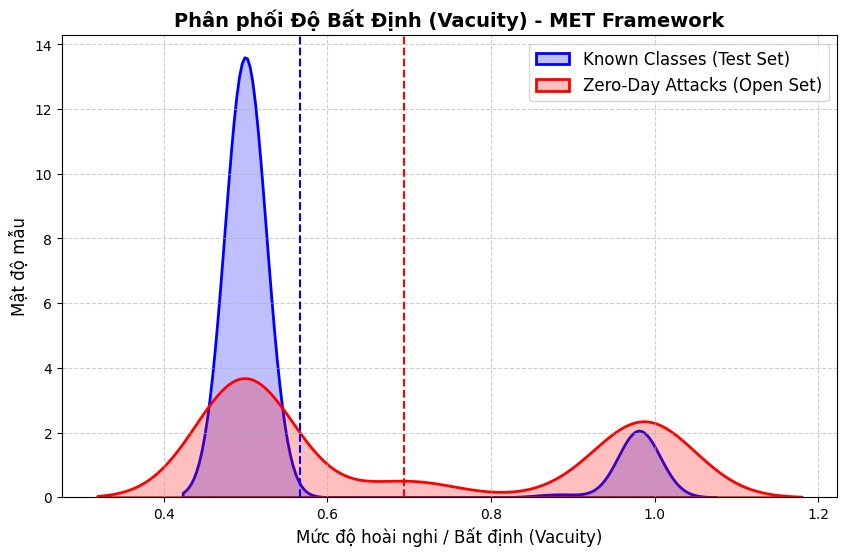

In [16]:
# ============================================================================
# CELL 11: ZERO-DAY DETECTION (EVALUATING UNCERTAINTY / VACUITY)
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "="*60)
print("PHASE 6: ZERO-DAY DETECTION VIA EVIDENTIAL UNCERTAINTY")
print("="*60)

model.eval()

with torch.no_grad():
    # 1. TRÍCH XUẤT PROTOTYPES TỪ TẬP TRAIN (Global Support Set)
    print(" Đang trích xuất Prototypes chuẩn từ tập Train...")
    support_x = []
    for cls in range(CLOSED_WAY):
        all_idx = np.where(y_train_encoded == cls)[0] 
        if len(all_idx) < SHOT:
            print(f" Cảnh báo: Lớp {cls} chỉ có {len(all_idx)} mẫu, ít hơn SHOT={SHOT}")
            idx = all_idx
        else:
            idx = all_idx[:SHOT]
            
        # Lấy dữ liệu (Đảm bảo X_train_scaled là numpy array)
        samples = X_train_scaled[idx]
        support_x.append(samples)
    
    support_x = torch.tensor(np.vstack(support_x), dtype=torch.float32).to(device)
    
    # Đưa qua Backbone và tinh chỉnh bằng FEAT Attention
    support_features = model.backbone(support_x) # Lúc này shape sẽ chuẩn xác là (50, 256)
    support_features = support_features.view(CLOSED_WAY, SHOT, EMB_DIM)
    proto = support_features.mean(dim=1) # (Way, 256)
    
    proto = proto.unsqueeze(0)
    proto, _ = model.slf_attn(proto, proto, proto)
    proto = proto.squeeze(0) # (Way, 256)

    # 2. HÀM TÍNH ĐỘ BẤT ĐỊNH (VACUITY) CHO TẬP DỮ LIỆU BẤT KỲ
    def predict_vacuity(X_data, batch_size=512):
        dataset = torch.utils.data.TensorDataset(torch.tensor(X_data, dtype=torch.float32))
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
        
        vacuities = []
        # 1. Thêm block no_grad() để tắt đồ thị tính toán
        with torch.no_grad():
            for batch in loader:
                # Lấy tensor X ra khỏi Tuple của Dataloader một cách an toàn
                inputs = batch[0].to(device)
                
                q = model.backbone(inputs)
                
                # Tính khoảng cách Euclidean
                q_exp = q.unsqueeze(1) # (batch, 1, 256)
                p_exp = proto.unsqueeze(0) # (1, Way, 256)
                dist_sq = torch.sum((q_exp - p_exp)**2, dim=-1)
                
                # Tính Bằng chứng (Evidence) bằng hàm Exponential Decay
                evidence = 10.0 * torch.exp(-dist_sq)
                
                # Tính Độ bất định (Vacuity) theo công thức của Subjective Logic (MET)
                S = torch.sum(evidence, dim=1) + CLOSED_WAY
                u = CLOSED_WAY / S
                
                # 2. Thêm .detach() trước khi gọi .cpu().numpy() để an toàn tuyệt đối
                vacuities.extend(u.detach().cpu().numpy())
                
        return np.array(vacuities)

    # 3. CHẠY THỬ NGHIỆM TRÊN 2 TẬP DỮ LIỆU
    print(" ⏳ Đang quét tập Test (Known)...")
    vacuity_known = predict_vacuity(X_test_scaled)
    
    # Tách riêng tập Opponent (để dùng cho Phase 8)
    mask_opp = np.isin(y_test_encoded, le.transform(groups['OPPONENT']))
    X_test_opponent = X_test_scaled[mask_opp]
    print(" ⏳ Đang quét tập Opponent (DoS variants)...")
    vacuity_opponent = predict_vacuity(X_test_opponent)

    print(" ⏳ Đang quét tập Zero-day (Unknown)...")
    vacuity_zero = predict_vacuity(X_zero_scaled)

# 4. IN KẾT QUẢ VÀ TRỰC QUAN HÓA
print("\n" + "="*60)
print(" KẾT QUẢ PHÁT HIỆN ZERO-DAY (VACUITY SCORE)")
print("="*60)
print(f" Trung bình Độ bất định của nhóm ĐÃ BIẾT (Known):   {np.mean(vacuity_known):.4f}")
print(f" Trung bình Độ bất định của nhóm ZERO-DAY (Unknown): {np.mean(vacuity_zero):.4f}")

# Vẽ biểu đồ phân phối
plt.figure(figsize=(10, 6))
sns.kdeplot(vacuity_known, fill=True, color="blue", label="Known Classes (Test Set)", linewidth=2)
sns.kdeplot(vacuity_zero, fill=True, color="red", label="Zero-Day Attacks (Open Set)", linewidth=2)
plt.axvline(x=np.mean(vacuity_known), color='blue', linestyle='--')
plt.axvline(x=np.mean(vacuity_zero), color='red', linestyle='--')

plt.title("Phân phối Độ Bất Định (Vacuity) - MET Framework", fontsize=14, fontweight='bold')
plt.xlabel("Mức độ hoài nghi / Bất định (Vacuity)", fontsize=12)
plt.ylabel("Mật độ mẫu", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


PHASE 7: COMPREHENSIVE EVALUATION & ALERT SYSTEM
 Đang trích xuất dự đoán trên tập Test (Closed-set)...

 BẢNG BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):
              precision    recall  f1-score   support

    ACKFLOOD       1.00      1.00      1.00      3000
      BENIGN       1.00      1.00      1.00      3000
   ICMPFLOOD       1.00      1.00      1.00      3000
    SYNFLOOD       1.00      1.00      1.00      3000

   micro avg       1.00      1.00      1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



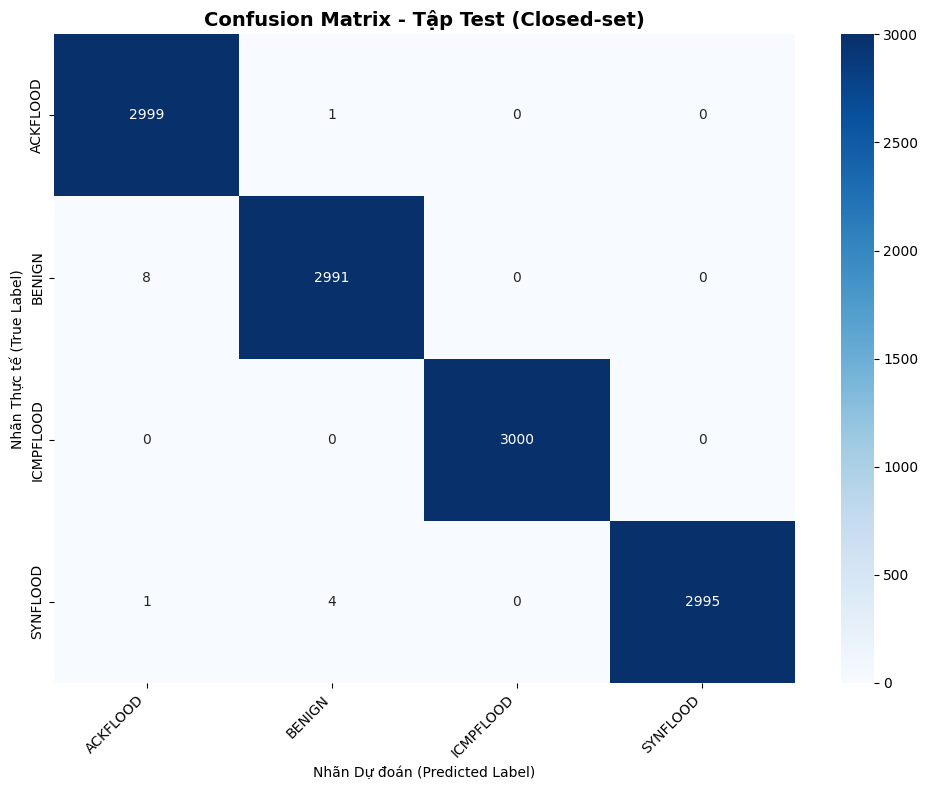


 ĐÁNH GIÁ HỆ THỐNG CẢNH BÁO ZERO-DAY (ALERT SYSTEM)
 Chỉ số AUROC (Khả năng tách biệt Zero-day): 0.5526
 Ngưỡng Cảnh Báo Tối Ưu (Optimal Vacuity Threshold): 0.5193


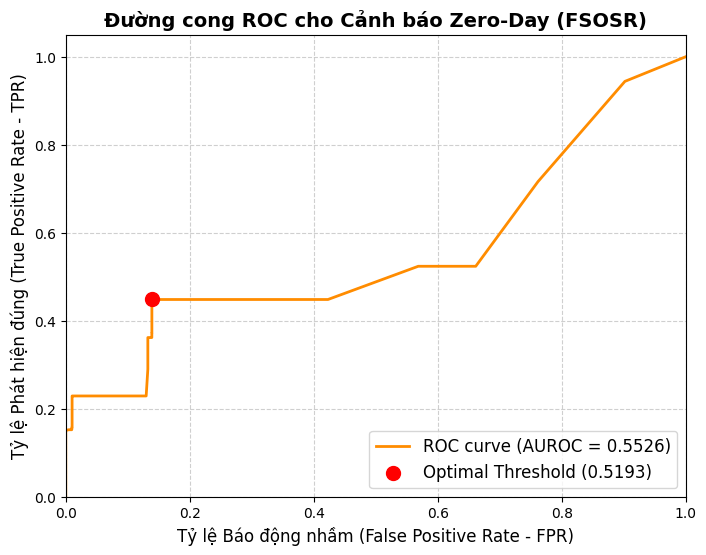


 BÁO CÁO HIỆU SUẤT HÚ CÒI (ALERT TRIGGER PERFORMANCE):
  - Tỷ lệ phát hiện trúng (Detection Rate / Recall): 44.70% (Bắt được 367/821 đòn Zero-Day)
  - Tỷ lệ báo động nhầm (False Alarm Rate / FPR) : 13.89% (Đánh nhầm 1706/12285 gói tin sạch)
  - Độ chính xác của còi báo (Alert Precision)   : 17.70%
  - Điểm F1-Score của còi báo                    : 0.2536


In [17]:
# ============================================================================
# CELL 12: TOÀN CẢNH ĐÁNH GIÁ MÔ HÌNH & HỆ THỐNG CẢNH BÁO SỚM
# ============================================================================
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

print("\n" + "="*60)
print("PHASE 7: COMPREHENSIVE EVALUATION & ALERT SYSTEM")
print("="*60)

# ============================================================================
# 1. ĐÁNH GIÁ KHẢ NĂNG NHẬN BIẾT LỚP ĐÃ BIẾT (CLOSED-SET CLASSIFICATION)
# ============================================================================
print(" Đang trích xuất dự đoán trên tập Test (Closed-set)...")

# Lọc chỉ lấy các mẫu thuộc nhóm CLOSED trong tập Test
mask_closed = np.isin(y_test_encoded, closed_classes_encoded)
X_test_closed = X_test_scaled[mask_closed]
y_test_closed = y_test_encoded[mask_closed]

# Hàm dự đoán lớp dựa trên Prototype (Khoảng cách Euclidean -> Evidence)
def predict_classes(X_data, batch_size=512):
    dataset = torch.utils.data.TensorDataset(torch.tensor(X_data, dtype=torch.float32))
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
    preds = []
    
    with torch.no_grad():
        for batch in loader:
            inputs = batch[0].to(device)
            q = model.backbone(inputs) # (batch, 256)
            q_exp = q.unsqueeze(1)
            p_exp = proto.unsqueeze(0)
            dist_sq = torch.sum((q_exp - p_exp)**2, dim=-1)
            evidence = 10.0 * torch.exp(-dist_sq)
            preds.extend(torch.argmax(evidence, dim=1).cpu().numpy())
    return np.array(preds)

y_pred_closed = predict_classes(X_test_closed)

# Chuyển đổi nhãn số về tên chữ thực tế để hiển thị cho đẹp
y_test_names = le.inverse_transform(y_test_closed)
y_pred_names = le.inverse_transform(y_pred_closed)

unique_labels_present = np.unique(y_test_names)
print("\n BẢNG BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):")
print(classification_report(y_test_names, y_pred_names, labels=unique_labels_present))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_test_names, y_pred_names, labels=unique_labels_present)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels_present, yticklabels=unique_labels_present)
plt.title("Confusion Matrix - Tập Test (Closed-set)", fontsize=14, fontweight='bold')
plt.ylabel('Nhãn Thực tế (True Label)')
plt.xlabel('Nhãn Dự đoán (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# ============================================================================
# 2. ĐÁNH GIÁ KHẢ NĂNG TÁCH LỚP ZERO-DAY & TÌM NGƯỠNG CẢNH BÁO
# ============================================================================
print("\n" + "="*60)
print(" ĐÁNH GIÁ HỆ THỐNG CẢNH BÁO ZERO-DAY (ALERT SYSTEM)")
print("="*60)

# Gom chung Vacuity của 2 tập (Đã biết = 0, Zero-Day = 1)
# vacuity_known và vacuity_zero được kế thừa từ CELL 11
y_true_alert = np.concatenate([np.zeros_like(vacuity_known), np.ones_like(vacuity_zero)])
y_scores_alert = np.concatenate([vacuity_known, vacuity_zero])

# Tính toán ROC Curve và AUROC
fpr, tpr, thresholds = roc_curve(y_true_alert, y_scores_alert)
roc_auc = auc(fpr, tpr)

# Tìm Ngưỡng tối ưu (Optimal Threshold) bằng chỉ số Youden's J statistic
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f" Chỉ số AUROC (Khả năng tách biệt Zero-day): {roc_auc:.4f}")
print(f" Ngưỡng Cảnh Báo Tối Ưu (Optimal Vacuity Threshold): {optimal_threshold:.4f}")

# Vẽ biểu đồ ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUROC = {roc_auc:.4f})')
plt.plot([3], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, label=f'Optimal Threshold ({optimal_threshold:.4f})', zorder=5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Báo động nhầm (False Positive Rate - FPR)', fontsize=12)
plt.ylabel('Tỷ lệ Phát hiện đúng (True Positive Rate - TPR)', fontsize=12)
plt.title('Đường cong ROC cho Cảnh báo Zero-Day (FSOSR)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ============================================================================
# 3. MÔ PHỎNG HIỆU SUẤT CỦA BỘ CẢNH BÁO (ALERT PERFORMANCE)
# ============================================================================
# Mô phỏng: Nếu Vacuity > optimal_threshold thì hú còi Alert (Dự đoán là Zero-day)
alerts_triggered = (y_scores_alert > optimal_threshold).astype(int)

# Đánh giá riêng cho bộ phận Cảnh báo
alert_cm = confusion_matrix(y_true_alert, alerts_triggered)
alert_tn, alert_fp, alert_fn, alert_tp = alert_cm.ravel()

alert_precision = alert_tp / (alert_tp + alert_fp) if (alert_tp + alert_fp) > 0 else 0
alert_recall = alert_tp / (alert_tp + alert_fn) if (alert_tp + alert_fn) > 0 else 0
alert_f1 = 2 * (alert_precision * alert_recall) / (alert_precision + alert_recall) if (alert_precision + alert_recall) > 0 else 0

print("\n BÁO CÁO HIỆU SUẤT HÚ CÒI (ALERT TRIGGER PERFORMANCE):")
print(f"  - Tỷ lệ phát hiện trúng (Detection Rate / Recall): {alert_recall*100:.2f}% (Bắt được {alert_tp}/{alert_tp+alert_fn} đòn Zero-Day)")
print(f"  - Tỷ lệ báo động nhầm (False Alarm Rate / FPR) : {alert_fp/(alert_fp+alert_tn)*100:.2f}% (Đánh nhầm {alert_fp}/{alert_fp+alert_tn} gói tin sạch)")
print(f"  - Độ chính xác của còi báo (Alert Precision)   : {alert_precision*100:.2f}%")
print(f"  - Điểm F1-Score của còi báo                    : {alert_f1:.4f}")


PHASE 8: GLOBAL IDS PIPELINE EVALUATION
⏳ Đang chuẩn bị dữ liệu Vacuity cho báo cáo tổng thể...
 Đã chuẩn bị xong:
 - X_test_closed: 12000 mẫu
 - X_test_opponent: 285 mẫu
 - X_zero_scaled: 821 mẫu
⏳ Đang chạy IDS Router để phân luồng toàn bộ gói tin...

 BÁO CÁO HIỆU SUẤT ĐÁNH CHẶN TỔNG THỂ (GLOBAL IDS METRICS)
 Tổng số gói tin tấn công thực tế : 10106
 Tổng số gói tin bình thường      : 3000

 Tỷ lệ chẩn đoán đúng (Accuracy)  : 97.02%
 Tỷ lệ tóm gọn tấn công (Recall)  : 96.58% (Chặn được 9760/10106 đòn)
 Tỷ lệ BỎ LỌT tấn công (Miss Rate): 3.42% (Bị lọt 346 đòn) <-- CHỈ SỐ BẠN QUAN TÂM
 Tỷ lệ báo động nhầm (False Alarm): 1.47% (Nhận diện nhầm 44 gói tin sạch)


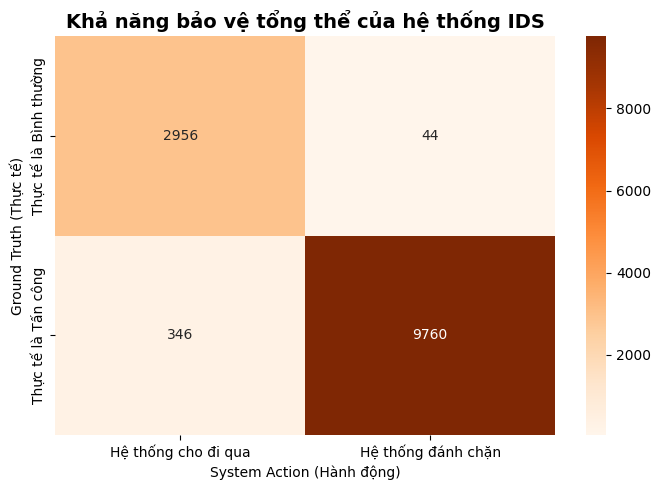


Thống kê hành động của bộ lọc IDS:
 - NORMAL: 3302 lần
 - KNOWN_ALERT (SYNFLOOD): 3103 lần
 - KNOWN_ALERT (ACKFLOOD): 3007 lần
 - UNKNOWN_ALERT: 2073 lần
 - KNOWN_ALERT (ICMPFLOOD): 1621 lần


In [20]:
# ============================================================================
# CELL 13: ĐÁNH GIÁ TỔNG THỂ HỆ THỐNG IDS (NORMAL vs ALL ATTACKS)
# ============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("PHASE 8: GLOBAL IDS PIPELINE EVALUATION")
print("="*60)

# 1. Xác định ID của các lớp Opponent (đã mã hóa bằng LabelEncoder)
# Giả sử 'groups' đã được định nghĩa từ get_dynamic_met_groups
opponent_classes_encoded = le.transform(groups['OPPONENT'])
opponent_classes_tensor = torch.tensor(opponent_classes_encoded, dtype=torch.long, device=device)

# 2. Tách X_test_opponent từ tập Test chung (Anti-leakage)
mask_opponent = np.isin(y_test_encoded, opponent_classes_encoded)
X_test_opponent = X_test_scaled[mask_opponent]
y_test_opponent = y_test_encoded[mask_opponent]

# 3. Tính toán Vacuity cho từng nhóm (Nếu chưa tính ở Cell trước)
print("⏳ Đang chuẩn bị dữ liệu Vacuity cho báo cáo tổng thể...")
vacuity_closed = predict_vacuity(X_test_closed)     # Nhóm an toàn/tấn công đã học
vacuity_opponent = predict_vacuity(X_test_opponent) # Nhóm đối thủ (giả lập unknown lúc train)
# vacuity_zero đã có từ Cell 11

print(f" Đã chuẩn bị xong:")
print(f" - X_test_closed: {X_test_closed.shape[0]} mẫu")
print(f" - X_test_opponent: {X_test_opponent.shape[0]} mẫu")
print(f" - X_zero_scaled: {X_zero_scaled.shape[0]} mẫu")

# 1. GỘP TOÀN BỘ DỮ LIỆU ĐỂ ĐÁNH GIÁ THỰC CHIẾN
# Sử dụng X_test_closed (từ Cell 12), X_test_opponent (từ Cell 12), và X_zero_scaled
X_eval_all = np.vstack([X_test_closed, X_test_opponent, X_zero_scaled])

# Lấy nhãn thực tế dạng Text
y_true_closed_names = le.inverse_transform(y_test_closed)
y_true_opponent_names = le.inverse_transform(y_test_opponent)
y_zero_names = y_zero.values if hasattr(y_zero, 'values') else np.array(y_zero)

y_true_all_names = np.concatenate([y_true_closed_names, y_true_opponent_names, y_zero_names])

# Gộp Vacuity đã tính trước đó
vacuity_all = np.concatenate([vacuity_closed, vacuity_opponent, vacuity_zero])

# 2. DỰ ĐOÁN LỚP (PREDICTED CLASS) CHO TOÀN BỘ DỮ LIỆU
print("⏳ Đang chạy IDS Router để phân luồng toàn bộ gói tin...")
preds_all_encoded = predict_classes(X_eval_all)
preds_all_names = le.inverse_transform(preds_all_encoded)

# 3. MÔ PHỎNG LOGIC IDS 3 TẦNG
y_true_binary = [] # 0: Normal, 1: Attack
y_pred_binary = [] # 0: Pass, 1: Alert Blocked
system_logs = []

X_unknown = [] 
y_unknown_true_labels = []

for i in range(len(X_eval_all)):
    actual_label = y_true_all_names[i]
    pred_class = preds_all_names[i]
    vac = vacuity_all[i]
    
    # Label thực tế (Binary)
    is_actual_attack = 0 if actual_label == "BENIGN" else 1
    y_true_binary.append(is_actual_attack)
    
    # Logic Hệ thống (IDS Router)
    if vac > optimal_threshold:
        y_pred_binary.append(1) # Kích hoạt còi
        system_logs.append("UNKNOWN_ALERT")
        X_unknown.append(X_eval_all[i])
        y_unknown_true_labels.append(y_true_all_names[i])
    else:
        if pred_class == "BENIGN":
            y_pred_binary.append(0) # Cho đi qua
            system_logs.append("NORMAL")
        else:
            y_pred_binary.append(1) # Kích hoạt còi
            system_logs.append(f"KNOWN_ALERT ({pred_class})")

X_unknown = np.array(X_unknown)
y_true_binary = np.array(y_true_binary)
y_pred_binary = np.array(y_pred_binary)

# 4. TÍNH TOÁN CÁC CHỈ SỐ QUAN TRỌNG NHẤT MÀ BẠN YÊU CẦU
cm_global = confusion_matrix(y_true_binary, y_pred_binary)
tn, fp, fn, tp = cm_global.ravel()

total_attacks = tp + fn
total_normals = tn + fp

detection_rate = (tp / total_attacks) * 100 if total_attacks > 0 else 0
miss_rate = (fn / total_attacks) * 100 if total_attacks > 0 else 0
false_alarm_rate = (fp / total_normals) * 100 if total_normals > 0 else 0
accuracy = ((tp + tn) / (total_attacks + total_normals)) * 100

print("\n" + "="*60)
print(" BÁO CÁO HIỆU SUẤT ĐÁNH CHẶN TỔNG THỂ (GLOBAL IDS METRICS)")
print("="*60)
print(f" Tổng số gói tin tấn công thực tế : {total_attacks}")
print(f" Tổng số gói tin bình thường      : {total_normals}\n")

print(f" Tỷ lệ chẩn đoán đúng (Accuracy)  : {accuracy:.2f}%")
print(f" Tỷ lệ tóm gọn tấn công (Recall)  : {detection_rate:.2f}% (Chặn được {tp}/{total_attacks} đòn)")
print(f" Tỷ lệ BỎ LỌT tấn công (Miss Rate): {miss_rate:.2f}% (Bị lọt {fn} đòn) <-- CHỈ SỐ BẠN QUAN TÂM")
print(f" Tỷ lệ báo động nhầm (False Alarm): {false_alarm_rate:.2f}% (Nhận diện nhầm {fp} gói tin sạch)")

# 5. VẼ GLOBAL CONFUSION MATRIX
plt.figure(figsize=(7, 5))
sns.heatmap(cm_global, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Hệ thống cho đi qua', 'Hệ thống đánh chặn'], 
            yticklabels=['Thực tế là Bình thường', 'Thực tế là Tấn công'])
plt.title("Khả năng bảo vệ tổng thể của hệ thống IDS", fontsize=14, fontweight='bold')
plt.ylabel('Ground Truth (Thực tế)')
plt.xlabel('System Action (Hành động)')
plt.tight_layout()
plt.show()

# 6. THỐNG KÊ CHI TIẾT CÁC LỜI CẢNH BÁO (SYSTEM LOGS)
print("\nThống kê hành động của bộ lọc IDS:")
log_counts = pd.Series(system_logs).value_counts()
for log_type, count in log_counts.items():
    print(f" - {log_type}: {count} lần")